In [ ]:
import healpy as hp
alms_cmb= hp.synalm(cl_cmb,lmax=lmax)
alms_noise = hp.synalm(cl_noise,lmax=lmax)
test_cl = hp.alm2cl(alms_cmb+alms_noise)

: 

 LV sbi code below to adaptb- look at simulators and noise functions. Also no. paramaters must change etc.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from joblib import Parallel, delayed
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.analysis import plot_summary

_ = torch.manual_seed(42)

_ = np.random.seed(0)

# Define Lotka Volterra Simulator
def lotka_volterra(y, alpha, beta, delta, gamma):
    prey, predator = y
    dprey_dt = alpha * prey - beta * prey * predator
    dpredator_dt = delta * prey * predator - gamma * predator
    return np.asarray([dprey_dt, dpredator_dt])

def simulate_total(parameters):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]

    y0 = np.asarray([40.0, 9.0])  # Initial populations
    t_span = 400  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

# split into two halves
def split_in_two(nparray):
    n = len(nparray)
    mid = n//2
    res1 = nparray[:mid]
    res2 = nparray[mid:]
    return res1, res2

# split by even/odd indices
def split_by_even_odd(nparray):
    even = nparray[::2]
    odd = nparray[1::2]
    return even, odd


# Define how populations evolve
def simulate(parameters, observation):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]


    y0 = np.asarray([observation[0, 0], observation[0, 1]])  # Initial populations
    t_span = 200  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

# Extract observed data
def extract_data(url):
    df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)
    df.index.name = 'Year'
    df.columns = ['Hare', 'Lynx']
    time_vec = df.index.values
    observation = df[['Hare', 'Lynx']].values
    print(observation.shape)
    n_obs = observation.shape[0]
    sigma_hare = 0.2 * np.std(observation[:, 0])   # 20% of hare std
    sigma_lynx = 0.2 * np.std(observation[:, 1])   # 20% of lynx std
    return time_vec, observation, n_obs, sigma_hare, sigma_lynx

# Plot figures for observed lynx hare populations
def plot_observed_data(time_vec, observation):
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    _ = ax.plot(time_vec, observation)
    _ = ax.legend(["Prey", "Predator"])
    _ = ax.set_xlabel("Time")
    _ = ax.set_ylabel("Population")

# Use mean and max as summary statistics
def summarize_simulation(simulation_result):

    prey_population = simulation_result[:, 0]
    predator_population = simulation_result[:, 1]
    
    summary = [
        np.max(prey_population).item(),
        np.max(predator_population).item(),
        np.mean(prey_population).item(),
        np.mean(predator_population).item()
    ]
    return np.asarray(summary)

# pick out n_obs points to ensure arrays are same size
def downsample_to_n_obs(sim_result, n_obs):
    # pick out n_obs points to ensure arrays are same size
    T = sim_result.shape[0]
    idx = np.linspace(0, T - 1, n_obs).astype(int)
    return sim_result[idx]

# returns data that is same size as observed, adding no noise
def simulate_match_data(parameters, n_obs,observation):
    # returns data that is same size as observed, adding no noise
    full_traj = simulate(parameters,observation)            # (2000, 2)
    return downsample_to_n_obs(full_traj, n_obs)  # (n_obs, 2)

# Returns simulations with gaussian noise added
def simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation):
    latent = simulate_match_data(parameters, n_obs,observation)
    noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=latent.shape
    )
    # Column 0 ~ N(0, sigma_hare^2), column 1 ~ N(0, sigma_lynx^2)
    noisy = latent + noise
    return noisy

# Return simulations with poissoin noise added
def simulate_poisson(parameters, n_obs, observation):
    latent = simulate_match_data(parameters, n_obs, observation)
    lam = np.clip(latent, 1e-6, None)
    noisy_counts = np.random.poisson(lam)
    return noisy_counts

# Wrapper function to choose noise
def simulator_distribution(distn, parameters, n_obs, sigma_hare, sigma_lynx, observation):
    if distn == 'none':
        result = simulate_match_data(parameters, n_obs, observation)
    elif distn == 'gaussian':
        result = simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation)
    elif distn == 'poisson':
        result = simulate_poisson(parameters, n_obs, observation)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    return result

# Define a uniform prior
def define_uniform_prior():
    lower_bound = torch.as_tensor([0.05, 0.01, 0.005, 0.005])
    upper_bound = torch.as_tensor([0.15, 0.03, 0.03, 0.15])
    prior = BoxUniform(low=lower_bound, high=upper_bound)
    return prior

# Define a log-normal prior
def define_logn_prior():
    log_means = torch.log(torch.tensor([
        0.1,   # alpha - 1.6
        0.02,   # beta - 3.2
        0.015,  # delta - 0.6
        0.08    # gamma - 0.56
    ]))

    log_stds = torch.tensor([0.3, 0.3, 0.3, 0.3])

    # Build prior
    base_dist = LogNormal(loc=log_means, scale=log_stds)
    prior_lognormal = Independent(base_dist, 1)
    return prior_lognormal


# Wrapper Function to choose prior distn
def choose_prior_and_generate_theta(distn):
    if distn == 'uniform':
        prior = define_uniform_prior()
    elif distn == 'logn':
        prior = define_logn_prior()
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    
    theta = prior.sample((10_000,))
    return prior, theta

# simulator function
def parallel_simulate(theta,distn, n_obs, sigma_hare, sigma_lynx, observation):
    # Our simulator uses numpy, but prior samples are in PyTorch.
    theta_np = theta.numpy()

    num_workers = 8
    simulation_outputs = Parallel(n_jobs=num_workers)(
        delayed(simulator_distribution)(distn,batch,n_obs, sigma_hare, sigma_lynx, observation)
        for batch in theta_np
    )
    return np.asarray(simulation_outputs)

# generate simulations
def generate_x(theta,distn, n_obs,sigma_hare,sigma_lynx, observation):
    simulation_outputs = parallel_simulate(theta,distn, n_obs,sigma_hare, sigma_lynx, observation)
    x = torch.as_tensor(np.asarray([summarize_simulation(sim) for sim in simulation_outputs]), dtype=torch.float32)
    return x

# plot to check simulated data covers observed data
def plot_checker(x, x_obs):
        _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        limits=[[0, 200], [0, 150], [0, 25], [0, 50]],
        figsize=(4, 4),
    )


In [14]:

# Generate net, stopping after max epochs, choosing or not choosing to 
def train_net_generate_samples(x,theta,x_obs, prior, verbose, max_epoch,true_val):
    
    inference = NPE(prior= prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=max_epoch, stop_after_epochs=30)
    posterior_direct = inference.build_posterior(density_estimator=posterior_net,sample_with="direct")
    posterior_mcmc = inference.build_posterior(density_estimator=posterior_net,sample_with="mcmc")
    samples = posterior_mcmc.sample((1_000,), x=x_obs)

    if verbose == True:
        _ = plot_summary(
        inference,
        tags=["training_loss", "validation_loss"],
        figsize=(10, 2),
        )

        print(posterior_mcmc)
        print("Observation: ", x_obs)

        _ = pairplot(
            samples,
            points = true_val[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )
        
    return samples, posterior_mcmc, posterior_direct, inference

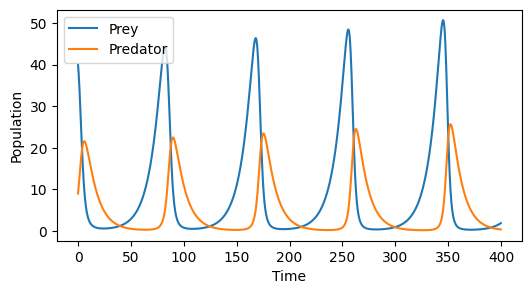

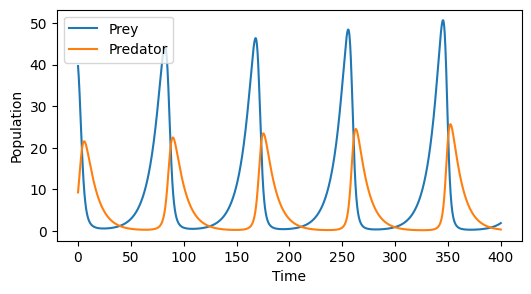

In [63]:
time_vec = np.arange(0, 400, 0.1)
true_parameters = np.asarray([0.1, 0.02, 0.01, 0.1])

observation = simulate_total(true_parameters)

time1, time2 = split_by_even_odd(time_vec)
obs1, obs2 = split_by_even_odd(observation)

plot_observed_data(time1, obs1)
plot_observed_data(time2, obs2)





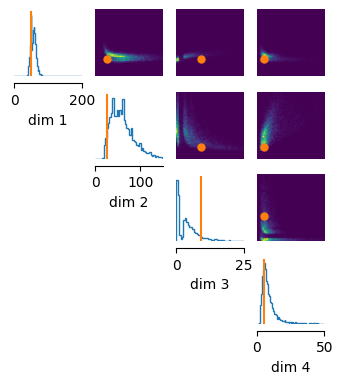

In [60]:
sigma_hare1 = 0.2 * np.std(obs1[:, 0])   # 20% of hare std
sigma_lynx1 = 0.2 * np.std(obs1[:, 1])   # 20% of lynx std
sigma_hare2 = 0.2 * np.std(obs2[:, 0])   # 20% of hare std
sigma_lynx2 = 0.2 * np.std(obs2[:, 1])   # 20% of lynx std
n_obs1 = len(obs1)
n_obs2 = len(obs2)

prior_name = 'uniform' #prior = 'logn'
noise1 =   'poisson' #'gaussian' 'none'
noise2 = 'gaussian'
max_epoch = 150

prior1,theta1 = choose_prior_and_generate_theta(prior_name)

x1 = generate_x(theta1,noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1)
x_obs1 = summarize_simulation(obs1)
plot_checker(x1,x_obs1)



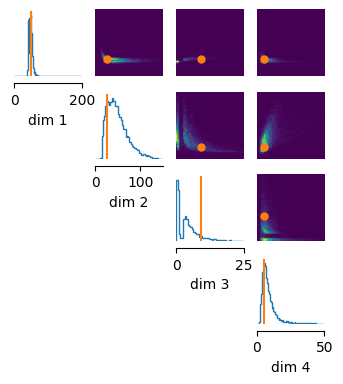

In [61]:
prior2,theta2 = choose_prior_and_generate_theta(prior_name)
x2 = generate_x(theta2,noise2, n_obs2, sigma_hare2, sigma_lynx2, obs2)
x_obs2 = summarize_simulation(obs2)
plot_checker(x2,x_obs2)

 Training neural network. Epochs trained: 151

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\sbi\inference\posteriors\mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  [50.69740598 25.66829405  9.28212424  5.33212511]


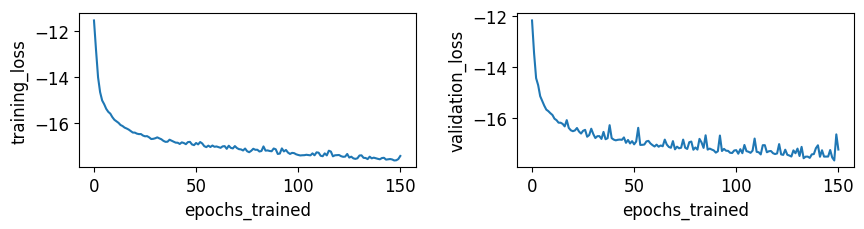

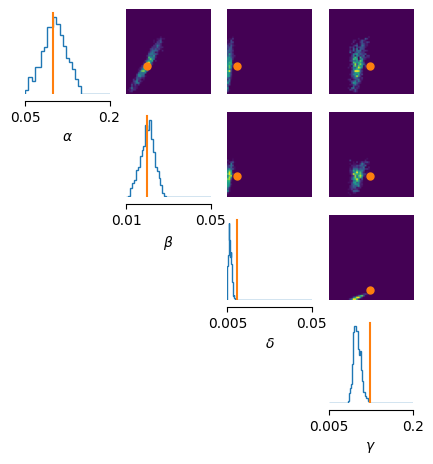

In [62]:
samples1, posterior1_mcmc, posterior1_direct, inference1 = train_net_generate_samples(x1,theta1,x_obs1, prior1, verbose = True, max_epoch=max_epoch, true_val=true_parameters)

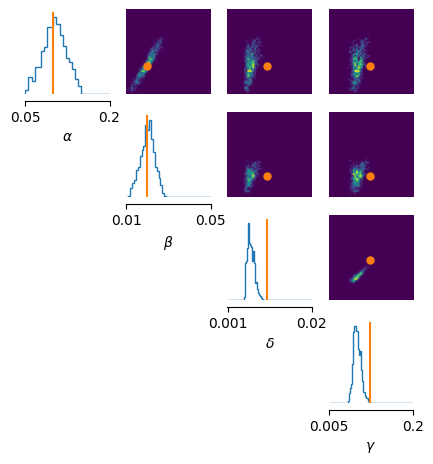

In [64]:
_ = pairplot(
            samples1,
            points = true_parameters[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )

 Training neural network. Epochs trained: 151

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\sbi\inference\posteriors\mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  [50.70120241 25.67033738  9.27255978  5.32999672]


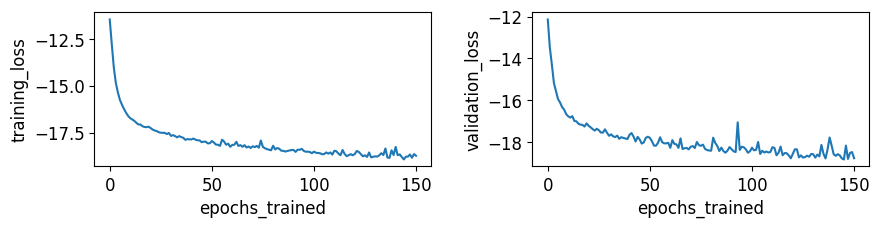

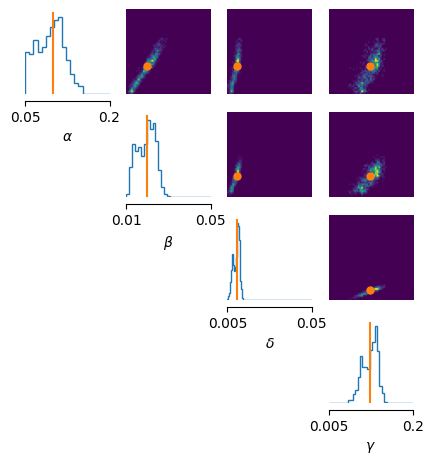

In [65]:
samples2, posterior2_mcmc, posterior2_direct, inference2 = train_net_generate_samples(x2,theta2,x_obs2, prior2, verbose = True, max_epoch=max_epoch, true_val=true_parameters)

In [ ]:
def calc_dkl(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        return (log_post1 - log_post2).mean().item()

def calibrate_null_dkl(null_posterior, prior, N, n_theta):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        traj_i = simulate_total(theta_i)
        obs1_i = traj_i[::2]
        obs2_i = traj_i[1::2]

        # - testing, get rid if bad
        m = min(len(obs1_i), len(obs2_i))
        obs1_i, obs2_i = obs1_i[:m], obs2_i[:m]
        #

        # Q: if we are using posterior 1 as a null, should we add whatever noise was added to train posterior 1 training data here?

        x1_i = summarize_simulation(obs1_i) 
        x2_i = summarize_simulation(obs2_i) #obtaining summary statistics of data

        dkls[i] = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    #plot histogram
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Null calibration of D_KL (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


0/100


                    accepted. It may take a long time to collect the remaining
                    433 samples. Consider interrupting (Ctrl-C) and switching to
                    `build_posterior(..., sample_with='mcmc')`.
                        constant for `log_prob()`. However, only
                        0.710% posterior samples are within the
                        prior support (for condition 0). It may take a long time
                        to collect the remaining 9929 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                 

20/100
40/100


                    accepted. It may take a long time to collect the remaining
                    430 samples. Consider interrupting (Ctrl-C) and switching to
                    `build_posterior(..., sample_with='mcmc')`.
                        constant for `log_prob()`. However, only
                        0.580% posterior samples are within the
                        prior support (for condition 0). It may take a long time
                        to collect the remaining 9942 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                 

60/100


                    accepted. It may take a long time to collect the remaining
                    473 samples. Consider interrupting (Ctrl-C) and switching to
                    `build_posterior(..., sample_with='mcmc')`.
                        constant for `log_prob()`. However, only
                        0.190% posterior samples are within the
                        prior support (for condition 0). It may take a long time
                        to collect the remaining 9981 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                 

80/100


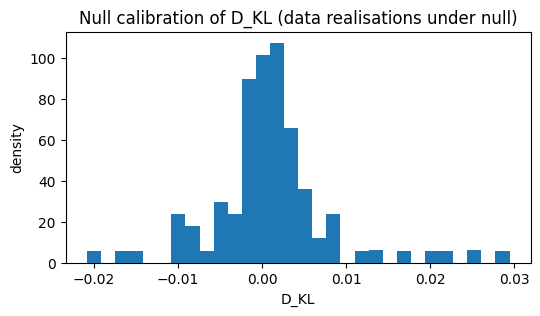

Null 95 percent critical value: 0.013950871909037224
DKL observed: 12.094837188720703


In [76]:

dkl_obs = calc_dkl(posterior1_direct, posterior2_direct, x_obs1, x_obs2, n_theta = 500)


dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, prior1, N=100, n_theta = 500)
print("DKL observed:", dkl_obs)        

